# 1. Set up

In [1]:
!pip install pandas
!pip install polars
!pip install scikit-learn
!pip install pyarrow
!pip install torch
!pip install xgboost category_encoders scikit-plot
!pip install pyproj
!pip install tqdm
!pip install hdbscan
!pip install scipy


# 2. Import necessary libraries

In [2]:
import pandas as pd
import polars as pl
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import pairwise_distances
from sklearn.model_selection import RepeatedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, precision_score, recall_score, f1_score
from collections import defaultdict

from sklearn.model_selection import train_test_split
import category_encoders as ce
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

from xgboost import plot_importance

# 3. Define global variables

In [3]:
INPUT_EVENTOS_FRAUDE_PATH = "../data/inputs/eventos_fraude_al_31_03_2025_v3.csv"
INPUT_EVENTOS_CONTROL_PATH = "../data/inputs/eventos_no_fraude_al_31_03_2025_all.csv"
INPUT_CONSUMOS_FRAUDE_PATH = "../data/inputs/consumos_fraude_al_31_03_2025_v3.csv"
INPUT_CONSUMOS_CONTROL_PATH = "../data/inputs/consumos_no_fraude_al_31_03_2025_all.csv"
INPUT_FRAUDES_PATH = "../data/inputs/fraudes_al_31_03_2025_fecha_fin.csv"

In [4]:
INPUT_EVENTOS_FRAUDE_PATH_ABRIL = "../data/inputs/eventos_fraude_al_30_04_2025_v3.csv"
INPUT_EVENTOS_CONTROL_PATH_ABRIL = "../data/inputs/eventos_no_fraude_al_30_04_2025_all.csv"
INPUT_CONSUMOS_FRAUDE_PATH_ABRIL = "../data/inputs/consumos_fraude_al_30_04_2025_v3.csv"
INPUT_CONSUMOS_CONTROL_PATH_ABRIL = "../data/inputs/consumos_no_fraude_al_30_04_2025_all.csv"
INPUT_FRAUDES_PATH_ABRIL = "../data/inputs/fraudes_al_30_04_2025_fecha_fin.csv"

In [5]:
train_losses = list()
train_losses_eval = list()
target_col = "target"

In [6]:
ufd_orange = "#f26122"
ufd_blue = "#003865"
ufd_gray = "#cccccc"

# 4. Functions

In [7]:
# nn.Module is the baseline of every model in PyTorch
class Autoencoder(nn.Module):
    def __init__(self, input_dim: int):
        # with super() we initialize the object nn.Module
        super().__init__()
        # We define the decoder that goes little by little reducing the dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), # 64 neurons for the first layer
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64,32), # 32 neurons for the second layer
            nn.ReLU(),
            nn.Linear(32, 16)
            
        )
        # We define the decoder that goes little by little upgrading the dim. Reconstruction part
        self.decoder = nn.Sequential(
            nn.Linear(16, 32), 
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64,input_dim)
        )

    def forward(self, x):
        """
        Forward method that defines how the information flows. It just simply applys the encoder-decoder
        architecture.
        """
        z = self.encoder(x)
        return self.decoder(z)

In [8]:
def crear_pivot_detallado(df: pd.DataFrame, 
                          columnas_inspecciones: list,
                          columnas_eventos: list) -> pd.DataFrame:
    """
    Crea un pivot manteniendo toda la información de conteos por combinación et-c
    """
    # Primero, crear una columna que combine et y c para identificar cada tipo de evento
    df_trabajo = df.copy()
    df_trabajo['tipo_evento'] = df_trabajo['et'].astype(str) + '_' + df_trabajo['c'].astype(str)
   
    # Crear el diccionario de agregación base
    agg_dict = {}
   
    # Para las columnas de inspecciones: tomar el primer valor (son iguales para cada grupo)
    for col in columnas_inspecciones:
        agg_dict[col] = 'first'
   
    # Para las columnas de eventos: necesitamos tratamiento especial
    # Las agregaremos después del groupby usando pivot
   
    # Primero hacer el groupby básico para las columnas de inspecciones
    resultado_base = df_trabajo.groupby(['cups_sgc', 'cnt_id']).agg(agg_dict).reset_index()
   
    # Ahora crear el pivot para las columnas de eventos manteniendo la granularidad
    eventos_pivot_list = []
   
    for col_evento in columnas_eventos:
        # Crear un pivot para cada columna de eventos
        pivot_temp = df_trabajo.pivot_table(
            index=['cups_sgc', 'cnt_id'],
            columns='tipo_evento',
            values=col_evento,
            aggfunc='sum',
            fill_value=0
        ).reset_index()
       
        # Renombrar las columnas para incluir el nombre de la columna original
        pivot_temp.columns = ['cups_sgc', 'cnt_id'] + [f"{col_evento}_{col}" for col in pivot_temp.columns[2:]]
       
        eventos_pivot_list.append(pivot_temp)
   
    # Unir todos los pivots de eventos
    resultado_eventos = eventos_pivot_list[0]
    for pivot in eventos_pivot_list[1:]:
        resultado_eventos = resultado_eventos.merge(
            pivot,
            on=['cups_sgc', 'cnt_id'],
            how='outer'
        )
   
    # Unir con el resultado base (inspecciones)
    resultado_final = resultado_base.merge(
        resultado_eventos,
        on=['cups_sgc', 'cnt_id'],
        how='outer'
    )
   
    return resultado_final

In [9]:
def plot_gain(y_true, y_proba):
    data = list(zip(y_true, y_proba))
    data = sorted(data, key=lambda x: x[1], reverse=True)
    y_sorted = np.array([d[0] for d in data])

    cum_gains = np.cumsum(y_sorted) / sum(y_sorted)
    perc_samples = np.arange(1, len(y_sorted)+1) / len(y_sorted)

    plt.figure(figsize=(7,6))
    plt.plot(perc_samples, cum_gains, color=ufd_orange, lw=2, label="Curva de ganancia")
    plt.plot([0,1], [0,1], linestyle="--", color=ufd_gray, label="Modelo aleatorio")

    # Estilo
    plt.grid(alpha=0.3)
    plt.xlabel("% de muestras")
    plt.ylabel("% de positivos acumulados")
    plt.title("Curva de Ganancia", fontsize=14, weight="bold", color=ufd_blue)
    plt.legend()
    plt.show()

In [10]:
def plot_lift(y_true, y_proba, bins=10):
    data = list(zip(y_true, y_proba))
    data = sorted(data, key=lambda x: x[1], reverse=True)
    y_sorted = np.array([d[0] for d in data])

    total_positives_rate = sum(y_sorted) / len(y_sorted)
    group_size = len(y_sorted) // bins
    lift = []

    for i in range(bins):
        start = i * group_size
        end = (i+1) * group_size if i < bins-1 else len(y_sorted)
        group = y_sorted[start:end]
        group_rate = sum(group) / len(group)
        lift.append(group_rate / total_positives_rate)

    # Percentiles crecientes (para graficar normalmente)
    percentiles = list(range(0, 101, int(100/bins)))[1:]  

    plt.figure(figsize=(7,6))
    plt.plot(percentiles, lift, marker="o", color=ufd_blue, lw=2)

    # Etiquetas con valores en cada punto
    for x, val in zip(percentiles, lift):
        plt.text(x, val+0.04, f"{val:.2f}", ha="center", fontsize=8, color=ufd_orange)

    plt.axhline(1, color=ufd_gray, linestyle="--")
    plt.grid(alpha=0.3)
    plt.xlabel("Percentiles")
    plt.ylabel("Lift")
    plt.title("Curva Lift", fontsize=14, weight="bold", color=ufd_blue)

    # Cambiar etiquetas del eje X: 100 → 0
    ticks = plt.xticks()[0]
    new_labels = [str(100 - int(t)) if t >= 0 and t <= 100 else "" for t in ticks]
    plt.xticks(ticks, new_labels)

    plt.show()

In [11]:
def ks_stat(y_true, y_proba):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    return max(tpr - fpr)

In [12]:
def get_probability_thresholds(y_test, predict_proba_test, cuts):
    """
    Computes the probability thresholds to split the population into groups 
    based on predicted probabilities.

    Example: if cuts = [15, 30], the function will return thresholds that 
    split the population into 3 groups:
        - Top 15% (high risk)
        - Next 15% (medium risk)
        - Remaining 70% (low risk)

    Parameters:
        - y_test: array-like. Ground truth labels (not used for thresholds, 
                  but kept for consistency if later needed).
        - predict_proba_test: list or np.array. Predicted probabilities for the positive class.
        - cuts: list of int. Cumulative percentages that define the split. 
                Values must be between 0 and 100, sorted in ascending order.

    Returns:
        - thresholds: list of float. Probability values that can be used as cut-offs
                      to assign groups.
    """

    # Sort probabilities in descending order
    sorted_proba = np.sort(predict_proba_test)[::-1]
    n = len(sorted_proba)
    
    thresholds = []
    for cut in cuts:
        # index corresponding to the cut (top % of population)
        idx = int(np.ceil(n * (cut/100)))
        # take the probability at that position as threshold
        thresholds.append(float(sorted_proba[idx-1]))  
    
    return thresholds

# 5. Code

## 5.1. Data processing

We will load the data, both the training and the validation data

In [13]:
eventos_fraude = pl.read_csv(INPUT_EVENTOS_FRAUDE_PATH)
eventos_control = pl.read_csv(INPUT_EVENTOS_CONTROL_PATH)
consumos_fraude = pl.read_csv(INPUT_CONSUMOS_FRAUDE_PATH).drop(["tuvo_fraude_previo", "tuvo_fraude_reciente", "estado_fraude"])
consumos_control = pl.read_csv(INPUT_CONSUMOS_CONTROL_PATH).drop(["tuvo_fraude_previo", "tuvo_fraude_reciente", "estado_fraude"])
fraudes = pd.read_csv(INPUT_FRAUDES_PATH).rename(columns={"cups": "cups_sgc", "fraudes_en_90_dias": "target"})

# sólo hay que pivotar la tabla de eventos para después unirla con las de consumos
eventos = pl.concat([eventos_control, eventos_fraude])
consumos = pl.concat([consumos_control, consumos_fraude])

In [14]:
print(len(eventos))
print(len(consumos)) 
print(len(fraudes))

454046
34612
3231


In [15]:
eventos_fraude_abril = pl.read_csv(INPUT_EVENTOS_FRAUDE_PATH_ABRIL)
eventos_control_abril = pl.read_csv(INPUT_EVENTOS_CONTROL_PATH_ABRIL)
consumos_fraude_abril = pl.read_csv(INPUT_CONSUMOS_FRAUDE_PATH_ABRIL).drop(["tuvo_fraude_previo", "tuvo_fraude_reciente", "estado_fraude"])
consumos_control_abril = pl.read_csv(INPUT_CONSUMOS_CONTROL_PATH_ABRIL).drop(["tuvo_fraude_previo", "tuvo_fraude_reciente", "estado_fraude"])
fraudes_abril = pd.read_csv(INPUT_FRAUDES_PATH_ABRIL).rename(columns={"cups": "cups_sgc", "fraudes_en_90_dias": "target"})

# sólo hay que pivotar la tabla de eventos para después unirla con las de consumos
eventos_abril = pl.concat([eventos_control_abril, eventos_fraude_abril])
consumos_abril = pl.concat([consumos_control_abril, consumos_fraude_abril])

In [16]:
# Extraemos las columnas numéricas de la tabla eventos
columnas_eventos = [col for col in eventos.columns if col not in ['cups_sgc', 'cnt_id', 'et', 'c'] and "eventos" in col]
columnas_inspecciones = [col for col in eventos.columns if col not in ['cups_sgc', 'cnt_id', 'et', 'c'] and "inspecciones" in col]

# Debemos rellenar los nulos de las columnas 'c' y 'et' antes de crear 'tipo_evento'
eventos = eventos.with_columns([
    pl.col("c").fill_null("NA").cast(pl.Utf8),
    pl.col("et").fill_null("NA").cast(pl.Utf8)
])
eventos_abril = eventos_abril.with_columns([
    pl.col("c").fill_null("NA").cast(pl.Utf8),
    pl.col("et").fill_null("NA").cast(pl.Utf8)
])

# Creación de la columna tipo_evento
eventos = eventos.with_columns(
    (pl.col("et") + "_" + pl.col("c")).alias("tipo_evento")
)
eventos_abril = eventos_abril.with_columns(
    (pl.col("et") + "_" + pl.col("c")).alias("tipo_evento")
)

Convertimos los polars data frames a pandas df:

In [17]:
eventos_df_pandas = eventos.to_pandas()
consumos_pandas = consumos.to_pandas()

eventos_df_pandas_abril = eventos_abril.to_pandas()
consumos_pandas_abril = consumos_abril.to_pandas()

Vamos a pivotar la tabla de eventos para tener un único valor de cups por cada fila:

In [18]:
# Ejecutar la función
print("Creando pivot detallado...")
eventos_pivotado_detallado = crear_pivot_detallado(eventos_df_pandas, columnas_inspecciones, columnas_eventos)
eventos_pivotado_detallado_abril = crear_pivot_detallado(eventos_df_pandas_abril, columnas_inspecciones, columnas_eventos)

Creando pivot detallado...


In [19]:
final_df = eventos_pivotado_detallado.merge(
    consumos.to_pandas(), on=["cups_sgc", "cnt_id"], how="outer"
).merge(fraudes, on=["cups_sgc"], how="left")

final_df.drop_duplicates(inplace=True)

final_df.head(10)

,cups_sgc,cnt_id,cnt_inspecciones_semana_actual,cnt_inspecciones_semana_pasada,cnt_inspecciones_misma_semana_anio_pasado,cnt_inspecciones_mes_actual,cnt_inspecciones_mes_pasado,cnt_inspecciones_mismo_mes_anio_pasado,cnt_inspecciones_trimestre_actual,cnt_inspecciones_trimestre_pasado,...,porcentaje_calidad_datos_trimestre_actual_incorrectos,porcentaje_calidad_datos_trimestre_pasado_correctos,porcentaje_calidad_datos_trimestre_pasado_incorrectos,porcentaje_calidad_datos_mismo_trimestre_anio_pasado_correctos,porcentaje_calidad_datos_mismo_trimestre_anio_pasado_incorrectos,porcentaje_calidad_datos_anio_actual_correctos,porcentaje_calidad_datos_anio_actual_incorrectos,porcentaje_calidad_datos_anio_anterior_correctos,porcentaje_calidad_datos_anio_anterior_incorrectos,target
0,ES0022000001000008QR1P,SAG0185769835,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,91.30,0.00,97.76,0.00,97.52,0.00,99.44,0.00,1.0
1,ES0022000001001149LS1P,SAG0185746454,0.0,0.0,0.0,0.0,28.0,0.0,28.0,0.0,...,0.00,91.30,0.00,97.76,0.00,95.81,0.03,75.35,0.01,NaN
2,ES0022000001001381YV1P,SAG0186400186,0.0,0.0,0.0,0.0,0.0,27.0,0.0,0.0,...,0.09,92.21,0.18,91.99,0.27,98.46,0.16,83.86,0.27,NaN
3,ES0022000001001663LT1P,ZIV0036507981,0.0,0.0,0.0,0.0,0.0,31.0,0.0,54.0,...,0.09,2.17,0.00,0.00,0.00,19.97,0.02,0.00,0.00,NaN
4,ES0022000001002279EH1P,ZIV0047987967,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,93.48,0.00,102.06,0.09,99.71,0.00,101.61,0.02,NaN
5,ES0022000001002372AL1P,SAG0185734056,0.0,0.0,0.0,0.0,29.0,0.0,29.0,0.0,...,0.00,78.26,0.00,98.86,0.00,91.50,0.02,99.72,0.00,NaN
6,ES0022000001005251ZT1P,SAG0185729235,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26.0,...,0.00,90.99,0.27,104.35,0.00,98.21,0.09,94.80,0.00,NaN
7,ES0022000001005425KJ1P,SAG0185748781,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28.0,...,0.00,90.17,0.00,95.56,0.00,98.06,0.00,99.70,0.00,NaN
8,ES0022000001006539RT1P,ZIV0050276191,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.00,0.00,0.00,0.00,1.53,0.03,0.00,0.00,NaN
9,ES0022000001007458VE1P,SAG0185748789,0.0,0.0,0.0,0.0,0.0,0.0,29.0,26.0,...,0.00,89.13,0.00,93.36,0.00,97.15,0.00,98.35,0.00,NaN


In [20]:
final_df_eval = eventos_pivotado_detallado_abril.merge(
    consumos_abril.to_pandas(), on=["cups_sgc", "cnt_id"], how="outer"
).merge(fraudes_abril, on=["cups_sgc"], how="left")

final_df_eval.drop_duplicates(inplace=True)

final_df_eval.head(10)

,cups_sgc,cnt_id,cnt_inspecciones_semana_actual,cnt_inspecciones_semana_pasada,cnt_inspecciones_misma_semana_anio_pasado,cnt_inspecciones_mes_actual,cnt_inspecciones_mes_pasado,cnt_inspecciones_mismo_mes_anio_pasado,cnt_inspecciones_trimestre_actual,cnt_inspecciones_trimestre_pasado,...,porcentaje_calidad_datos_trimestre_actual_incorrectos,porcentaje_calidad_datos_trimestre_pasado_correctos,porcentaje_calidad_datos_trimestre_pasado_incorrectos,porcentaje_calidad_datos_mismo_trimestre_anio_pasado_correctos,porcentaje_calidad_datos_mismo_trimestre_anio_pasado_incorrectos,porcentaje_calidad_datos_anio_actual_correctos,porcentaje_calidad_datos_anio_actual_incorrectos,porcentaje_calidad_datos_anio_anterior_correctos,porcentaje_calidad_datos_anio_anterior_incorrectos,target
0,ES0022000001001149LS1P,SAG0185746454,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28.0,...,0.28,97.78,0.00,100.00,0.00,95.35,0.06,75.35,0.01,NaN
1,ES0022000001001381YV1P,SAG0186400186,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.69,105.42,0.09,93.06,0.28,98.80,0.19,86.59,0.27,NaN
2,ES0022000001001663LT1P,ZIV0036507981,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.56,78.75,0.09,0.00,0.00,28.03,0.07,0.00,0.00,NaN
3,ES0022000001002279EH1P,ZIV0047987967,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.28,105.51,0.00,100.00,0.00,99.46,0.02,101.61,0.02,NaN
4,ES0022000001002372AL1P,SAG0185734056,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.0,...,0.28,90.05,0.00,96.67,0.00,86.10,0.05,99.44,0.00,NaN
5,ES0022000001005251ZT1P,SAG0185729235,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.28,112.18,0.00,100.00,0.00,98.01,0.11,94.80,0.00,NaN
6,ES0022000001005425KJ1P,SAG0185748781,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.28,105.51,0.00,96.67,0.00,97.88,0.02,99.43,0.00,NaN
7,ES0022000001006539RT1P,ZIV0050276191,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.00,0.00,0.00,0.00,1.53,0.03,0.00,0.00,NaN
8,ES0022000001007458VE1P,SAG0185748789,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.0,...,0.28,101.76,0.00,100.00,0.00,96.97,0.02,98.35,0.00,NaN
9,ES0022000001008220MW1P,SOG0100030751,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,0.23,0.00,0.00,0.14,8.58,1.37,8.55,0.31,NaN


### 5.1.2. Constant columns

We will delete those columns that have a unique value, thus, constant columns

In [21]:
constant_cols = []

for col in final_df.columns:
    if final_df[col].nunique() == 1 and col not in ['cups_sgc', 'cnt_id', target_col]:
        constant_cols.append(col)
        
        
final_df.drop(columns=constant_cols, inplace=True)

In [22]:
constant_cols_eval = []

for col in final_df_eval.columns:
    if final_df_eval[col].nunique() == 1 and col not in ['cups_sgc', 'cnt_id', target_col]:
        constant_cols_eval.append(col)
        
        
final_df_eval.drop(columns=constant_cols_eval, inplace=True)

### 5.1.3. Duplicated rows

Are there any duplicated rows in the data?

In [23]:
final_df[[col for col in final_df if col not in ['cups_sgc', 'cnt_id']]].duplicated().sum()

np.int64(10)

In [24]:
final_df_eval[[col for col in final_df_eval if col not in ['cups_sgc', 'cnt_id']]].duplicated().sum()

np.int64(10)

We observe that there are some little duplicated rows, we are going to delete them

In [25]:
final_df = final_df[~final_df[[col for col in final_df if col not in ['cups_sgc', 'cnt_id']]].duplicated()]

final_df_eval = final_df_eval[~final_df_eval[[col for col in final_df_eval if col not in ['cups_sgc', 'cnt_id']]].duplicated()]

In [26]:
final_df.head(5)

,cups_sgc,cnt_id,cnt_inspecciones_semana_actual,cnt_inspecciones_semana_pasada,cnt_inspecciones_misma_semana_anio_pasado,cnt_inspecciones_mes_actual,cnt_inspecciones_mes_pasado,cnt_inspecciones_mismo_mes_anio_pasado,cnt_inspecciones_trimestre_actual,cnt_inspecciones_trimestre_pasado,...,porcentaje_calidad_datos_trimestre_actual_incorrectos,porcentaje_calidad_datos_trimestre_pasado_correctos,porcentaje_calidad_datos_trimestre_pasado_incorrectos,porcentaje_calidad_datos_mismo_trimestre_anio_pasado_correctos,porcentaje_calidad_datos_mismo_trimestre_anio_pasado_incorrectos,porcentaje_calidad_datos_anio_actual_correctos,porcentaje_calidad_datos_anio_actual_incorrectos,porcentaje_calidad_datos_anio_anterior_correctos,porcentaje_calidad_datos_anio_anterior_incorrectos,target
0,ES0022000001000008QR1P,SAG0185769835,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,91.30,0.00,97.76,0.00,97.52,0.00,99.44,0.00,1.0
1,ES0022000001001149LS1P,SAG0185746454,0.0,0.0,0.0,0.0,28.0,0.0,28.0,0.0,...,0.00,91.30,0.00,97.76,0.00,95.81,0.03,75.35,0.01,NaN
2,ES0022000001001381YV1P,SAG0186400186,0.0,0.0,0.0,0.0,0.0,27.0,0.0,0.0,...,0.09,92.21,0.18,91.99,0.27,98.46,0.16,83.86,0.27,NaN
3,ES0022000001001663LT1P,ZIV0036507981,0.0,0.0,0.0,0.0,0.0,31.0,0.0,54.0,...,0.09,2.17,0.00,0.00,0.00,19.97,0.02,0.00,0.00,NaN
4,ES0022000001002279EH1P,ZIV0047987967,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,93.48,0.00,102.06,0.09,99.71,0.00,101.61,0.02,NaN


### 5.1.3. Variables selection

In [27]:
# final_df.drop(columns=[col for col in final_df.columns if "porcentaje" in col], inplace=True)
# final_df.drop(columns=[col for col in final_df.columns if "consumo_zero" in col], inplace=True)

We extract the categorical and continuous columns as well as we define the X and y sets

In [28]:
cat_cols = final_df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [col for col in cat_cols if col not in ['cups_sgc', 'cnt_id', target_col]]

X = final_df.drop(columns=[target_col, 'cups_sgc', 'cnt_id'], errors='ignore')
y = final_df[target_col]

X_eval = final_df_eval.drop(columns=[target_col, 'cups_sgc', 'cnt_id'], errors='ignore')
y_eval = final_df_eval[target_col]

In [29]:
X = X.apply(pd.to_numeric, errors='coerce')

# Opción 1: rellenar NaN con 0
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

# Clip very large/small values to avoid dtype errors
X = X.clip(lower=-1e6, upper=1e6)

X.head(5)

,cnt_inspecciones_semana_actual,cnt_inspecciones_semana_pasada,cnt_inspecciones_misma_semana_anio_pasado,cnt_inspecciones_mes_actual,cnt_inspecciones_mes_pasado,cnt_inspecciones_mismo_mes_anio_pasado,cnt_inspecciones_trimestre_actual,cnt_inspecciones_trimestre_pasado,cnt_inspecciones_mismo_trimestre_anio_pasado,cnt_inspecciones_anio_actual,...,porcentaje_calidad_datos_trimestre_actual_correctos,porcentaje_calidad_datos_trimestre_actual_incorrectos,porcentaje_calidad_datos_trimestre_pasado_correctos,porcentaje_calidad_datos_trimestre_pasado_incorrectos,porcentaje_calidad_datos_mismo_trimestre_anio_pasado_correctos,porcentaje_calidad_datos_mismo_trimestre_anio_pasado_incorrectos,porcentaje_calidad_datos_anio_actual_correctos,porcentaje_calidad_datos_anio_actual_incorrectos,porcentaje_calidad_datos_anio_anterior_correctos,porcentaje_calidad_datos_anio_anterior_incorrectos
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,98.84,0.00,91.30,0.00,97.76,0.00,97.52,0.00,99.44,0.00
1,0.0,0.0,0.0,0.0,28.0,0.0,28.0,0.0,0.0,84.0,...,97.78,0.00,91.30,0.00,97.76,0.00,95.81,0.03,75.35,0.01
2,0.0,0.0,0.0,0.0,0.0,27.0,0.0,0.0,55.0,28.0,...,105.42,0.09,92.21,0.18,91.99,0.27,98.46,0.16,83.86,0.27
3,0.0,0.0,0.0,0.0,0.0,31.0,0.0,54.0,86.0,54.0,...,78.75,0.09,2.17,0.00,0.00,0.00,19.97,0.02,0.00,0.00
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28.0,...,105.51,0.00,93.48,0.00,102.06,0.09,99.71,0.00,101.61,0.02


In [30]:
X_eval = X_eval.apply(pd.to_numeric, errors='coerce')

# Opción 1: rellenar NaN con 0
X_eval = X_eval.replace([np.inf, -np.inf], np.nan)
X_eval = X_eval.fillna(0)

# Clip very large/small values to avoid dtype errors
X_eval = X_eval.clip(lower=-1e6, upper=1e6)

In [31]:
final_df_eval[target_col].value_counts()

target
1.0    2301
Name: count, dtype: int64

In [32]:
final_df[target_col].value_counts()

target
1.0    2109
Name: count, dtype: int64

## 5.2. Parte no supervisada

In [33]:
modelo_rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)

# Configura la validación cruzada.
# RepeatedKFold es una excelente opción.
# n_splits=5 divide tus datos en 5 "folds" o subconjuntos.
# n_repeats=2 repite todo el proceso 2 veces, lo que te da un total de 10 modelos
# y un ranking de importancia muy robusto.
cv = RepeatedKFold(n_splits=5, n_repeats=2, random_state=42)

# Un diccionario para guardar las importancias de cada columna
importances = defaultdict(list)

y.fillna(0, inplace=True)

# Bucle sobre los splits de validación cruzada
for train_index, val_index in cv.split(X, y):
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

    # Entrena el modelo en el subconjunto de entrenamiento
    modelo_rf.fit(X_train_fold, y_train_fold)

    # Guarda las importancias de las características
    for i, col in enumerate(X.columns):
        importances[col].append(modelo_rf.feature_importances_[i])

# Calcular la media de las importancias para cada columna
feature_importances_mean = {col: np.mean(imps) for col, imps in importances.items()}

# Convertir a una Serie de pandas para ordenar fácilmente
importances_series = pd.Series(feature_importances_mean).sort_values(ascending=False)

# Seleccionar las 100 mejores características
top_100_features = importances_series.head(70).index.tolist()

# Ahora puedes crear un nuevo DataFrame solo con esas columnas
X_top_100 = X[top_100_features]

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [col for col in cat_cols if col not in ['cups_sgc', 'cnt_id', target_col]]

In [34]:
modelo_rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)

# Configura la validación cruzada.
# RepeatedKFold es una excelente opción.
# n_splits=5 divide tus datos en 5 "folds" o subconjuntos.
# n_repeats=2 repite todo el proceso 2 veces, lo que te da un total de 10 modelos
# y un ranking de importancia muy robusto.
cv = RepeatedKFold(n_splits=5, n_repeats=2, random_state=42)

# Un diccionario para guardar las importancias de cada columna
importances = defaultdict(list)

y.fillna(0, inplace=True)
y_eval.fillna(0, inplace=True)

# Bucle sobre los splits de validación cruzada
for train_index, val_index in cv.split(X, y):
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

    # Entrena el modelo en el subconjunto de entrenamiento
    modelo_rf.fit(X_train_fold, y_train_fold)

    # Guarda las importancias de las características
    for i, col in enumerate(X.columns):
        importances[col].append(modelo_rf.feature_importances_[i])

# Calcular la media de las importancias para cada columna
feature_importances_mean = {col: np.mean(imps) for col, imps in importances.items()}

# Convertir a una Serie de pandas para ordenar fácilmente
importances_series = pd.Series(feature_importances_mean).sort_values(ascending=False)

# Seleccionar las 100 mejores características
top_100_features = importances_series.head(70).index.tolist()

# Ahora puedes crear un nuevo DataFrame solo con esas columnas
X_top_100 = X[top_100_features]
X_eval_top_100 = X_eval[top_100_features]

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [col for col in cat_cols if col not in ['cups_sgc', 'cnt_id', target_col]]

In order to do the no supervised part, we need to scale the data since we are going to use distances within the models

In [35]:
scaler = StandardScaler()
# Ahora escalar
X_scaled = scaler.fit_transform(X)

scaler_eval = StandardScaler()
# Ahora escalar
X_scaled_eval = scaler_eval.fit_transform(X_eval)

### 5.2.1. Modelling

#### DBSCAN cluster

First of all we will use the DBSCAN model. This algorithm is a cluster algorithm based on density. Groups the data that have sufficient neighbors and everything that does not go into a cluster is labeled as -1. Thus, the idea is no more than finiding outliers in the data points.

In [36]:
# import hdbscan
# # Seteamos un radio de 3 alrededor de cada punto y un mínimo de 100 puntos requeridos dentro del vecindario para que un punto sea considerado un punto "core".
# hdb = hdbscan.HDBSCAN(cluster_selection_epsilon=3, min_samples=100).fit(X_scaled)

# cluster_labels = hdb.fit_predict(X_scaled)
# probabilities = hdb.probabilities_


# # Añadir al dataframe
# final_df["hdbscan_labels"] = cluster_labels
# final_df["hdbscan_probabilities"] = probabilities
# final_df["anomaly_dbscan"] = cluster_labels == -1

# print("Estadísticas de HDBSCAN:")
# print(f"Número de clusters: {len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)}")
# print(f"Outliers: {sum(cluster_labels == -1)}")
# print(f"Probabilidad media: {probabilities.mean():.3f}")

In [37]:
# final_df[final_df["anomaly_dbscan"] == 1]["hdbscan_probabilities"].unique()

In [38]:
# final_df["hdbscan_labels"].unique()

In [39]:
# final_df[final_df["hdbscan_labels"] == 0]["hdbscan_probabilities"].unique()

In [40]:
# Seteamos un radio de 3 alrededor de cada punto y un mínimo de 100 puntos requeridos dentro del vecindario para que un punto sea considerado un punto "core".
db = DBSCAN(eps=3, min_samples=100).fit(X_scaled)
# Identificamos outliers haciendo uso de la etiqueta -1
final_df["anomaly_dbscan"] = db.labels_ == -1
final_df["anomaly_dbscan"] = final_df["anomaly_dbscan"].astype(int)

In [41]:
# Calcular distancia promedio a todos los puntos core
core_samples = db.core_sample_indices_
if len(core_samples) > 0:
    # Distancia mínima a puntos core
    distances_to_core = pairwise_distances(X_scaled, X_scaled[core_samples])
    min_distances_to_core = distances_to_core.min(axis=1)
    
    # Normalizar distancias
    dbscan_scores = MinMaxScaler().fit_transform(
        min_distances_to_core.reshape(-1, 1)
    ).flatten()
    
    final_df["dbscan_distance_score"] = dbscan_scores

In [42]:
# final_df["anomaly_dbscan"].value_counts()

In [43]:
# Seteamos un radio de 3 alrededor de cada punto y un mínimo de 100 puntos requeridos dentro del vecindario para que un punto sea considerado un punto "core".
db_eval = DBSCAN(eps=3, min_samples=100).fit(X_scaled_eval)
# Identificamos outliers haciendo uso de la etiqueta -1
final_df_eval["anomaly_dbscan"] = db_eval.labels_ == -1
final_df_eval["anomaly_dbscan"] = final_df_eval["anomaly_dbscan"].astype(int)

In [44]:
core_samples_eval = db_eval.core_sample_indices_
if len(core_samples_eval) > 0:
    # Distancia mínima a puntos core
    distances_to_core_eval = pairwise_distances(X_scaled_eval, X_scaled_eval[core_samples_eval])
    min_distances_to_core_eval = distances_to_core_eval.min(axis=1)
    
    # Normalizar distancias
    dbscan_scores_eval = MinMaxScaler().fit_transform(
        min_distances_to_core_eval.reshape(-1, 1)
    ).flatten()
    
    final_df_eval["dbscan_distance_score"] = dbscan_scores_eval

In [45]:
# final_df_eval["anomaly_dbscan"].value_counts()

#### Isolation forest

Isolation forest es un modelo que trata de aislar los puntos de datos. Devuelve un -1 como un outlier y 1 como un punto "normal".

Isolation forest is a model that tries to aisle data points. It returns a -1 as an outlier and a 1 as a normal point. Thus, if we consider that a CUPS has a -1 prediction, it indicates that its metrics are far away from the general distribution.

In [46]:
from scipy.stats import rankdata
from scipy.special import expit

In [47]:
iso = IsolationForest(contamination=0.01, random_state=42)
preds = iso.fit_predict(X_scaled)

# Extraer scores continuos
anomaly_scores = iso.decision_function(X_scaled)

# Opción 1: MinMaxScaler (0-1)
# scaler_scores = MinMaxScaler()
# probabilities = scaler_scores.fit_transform(anomaly_scores.reshape(-1, 1)).flatten()

# Opción 2: Transformación sigmoide
iso_probabilities_sigmoid = expit(anomaly_scores * 5)  # Multiplica por factor para ajustar sensibilidad

# Opción 3: Ranking percentil
# iso_probabilities_rank = rankdata(anomaly_scores) / len(anomaly_scores)

# Añadir al dataframe
final_df["iso_anomaly_scores"] = anomaly_scores
# final_df["iso_probabilities"] = probabilities
final_df["iso_prob_sigmoid"] = iso_probabilities_sigmoid
# final_df["iso_prob_rank"] = iso_probabilities_rank
final_df["anomaly_iso"] = preds == -1
final_df["anomaly_iso"] = final_df["anomaly_iso"].astype(int)


print("Información de Isolation Forest:")
print(f"Rango de scores: {anomaly_scores.min():.3f} a {anomaly_scores.max():.3f}")
# print(f"Rango de probabilidades: {probabilities.min():.3f} a {probabilities.max():.3f}")
print(f"Outliers detectados: {sum(preds == -1)}")
print(f"Rango de probabilidades sigmoid: {iso_probabilities_sigmoid.min():.3f} a {iso_probabilities_sigmoid.max():.3f}")
# print(f"Rango de probabilidades rank: {iso_probabilities_rank.min():.3f} a {iso_probabilities_rank.max():.3f}")

Información de Isolation Forest:
Rango de scores: -0.146 a 0.146
Outliers detectados: 350
Rango de probabilidades sigmoid: 0.326 a 0.675


In [48]:
print(f"Min: {final_df[final_df["anomaly_iso"] == 1]["iso_prob_sigmoid"].min()}, Max: {final_df[final_df["anomaly_iso"] == 1]["iso_prob_sigmoid"].max()}")

Min: 0.32558388997527565, Max: 0.49999132319044115


In [49]:
print(f"Min: {final_df[final_df["anomaly_iso"] == 0]["iso_prob_sigmoid"].min()}, Max: {final_df[final_df["anomaly_iso"] == 0]["iso_prob_sigmoid"].max()}")

Min: 0.5000274765635783, Max: 0.6748842575028514


In [50]:
iso_eval = IsolationForest(contamination=0.01, random_state=42)
preds_eval = iso_eval.fit_predict(X_scaled_eval)

# Extraer scores continuos
anomaly_scores_eval = iso_eval.decision_function(X_scaled_eval)

# Opción 1: MinMaxScaler (0-1)
# scaler_scores = MinMaxScaler()
# probabilities = scaler_scores.fit_transform(anomaly_scores.reshape(-1, 1)).flatten()

# Opción 2: Transformación sigmoide
iso_probabilities_sigmoid_eval = expit(anomaly_scores_eval * 5)  # Multiplica por factor para ajustar sensibilidad

# Opción 3: Ranking percentil
# iso_probabilities_rank = rankdata(anomaly_scores) / len(anomaly_scores)

# Añadir al dataframe
final_df_eval["iso_anomaly_scores"] = anomaly_scores_eval
# final_df["iso_probabilities"] = probabilities
final_df_eval["iso_prob_sigmoid"] = iso_probabilities_sigmoid_eval
# final_df["iso_prob_rank"] = iso_probabilities_rank
final_df_eval["anomaly_iso"] = preds_eval == -1
final_df_eval["anomaly_iso"] = final_df_eval["anomaly_iso"].astype(int)


print("Información de Isolation Forest:")
print(f"Rango de scores: {anomaly_scores_eval.min():.3f} a {anomaly_scores_eval.max():.3f}")
# print(f"Rango de probabilidades: {probabilities.min():.3f} a {probabilities.max():.3f}")
print(f"Outliers detectados: {sum(preds_eval == -1)}")
print(f"Rango de probabilidades sigmoid: {iso_probabilities_sigmoid_eval.min():.3f} a {iso_probabilities_sigmoid_eval.max():.3f}")
# print(f"Rango de probabilidades rank: {iso_probabilities_rank.min():.3f} a {iso_probabilities_rank.max():.3f}")

Información de Isolation Forest:
Rango de scores: -0.171 a 0.152
Outliers detectados: 363
Rango de probabilidades sigmoid: 0.299 a 0.681


#### Autoencoders

Now we are going to go with the approach of autoencoders. The idea here is to find big errors when the decoder tries to reconstruct the input. Then we will find anomalies within the magnitude of that error

In [51]:
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

# We create a PyTorch dataset that can be consumed by a DataLoader. TensorDataset is a way of evolving tensors
# as a simple dataset
train_data = TensorDataset(X_tensor)
# We create a data loader that divides the dataset in batches of 256 and shuffles the arrange randomly
loader = DataLoader(train_data, batch_size=256, shuffle=True)

In [52]:
model = Autoencoder(input_dim=X_tensor.shape[1])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [53]:
model.train()

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=953, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=953, bias=True)
  )
)

In [54]:
for epoch in range(60):
    model.train()
    running_loss = 0
    for batch in loader:
        # we take the batch[0] because TensorDataset only has one input tensor (without target)
        inputs = batch[0]
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        # we clear the gradients
        optimizer.zero_grad()
        # we calculate the gradients
        loss.backward()
        # we update the weights
        optimizer.step()
        running_loss += loss.item()

    train_losses.append(running_loss / len(loader))

    # Validation
    model.eval()

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_losses[-1]:.4f}")

Epoch 01 | Train Loss: 0.9247
Epoch 02 | Train Loss: 0.8191
Epoch 03 | Train Loss: 0.7852
Epoch 04 | Train Loss: 0.7639
Epoch 05 | Train Loss: 0.7436
Epoch 06 | Train Loss: 0.7294
Epoch 07 | Train Loss: 0.7185
Epoch 08 | Train Loss: 0.7029
Epoch 09 | Train Loss: 0.6940
Epoch 10 | Train Loss: 0.6849
Epoch 11 | Train Loss: 0.6918
Epoch 12 | Train Loss: 0.6737
Epoch 13 | Train Loss: 0.6737
Epoch 14 | Train Loss: 0.6658
Epoch 15 | Train Loss: 0.6532
Epoch 16 | Train Loss: 0.6415
Epoch 17 | Train Loss: 0.6384
Epoch 18 | Train Loss: 0.6346
Epoch 19 | Train Loss: 0.6257
Epoch 20 | Train Loss: 0.6239
Epoch 21 | Train Loss: 0.6270
Epoch 22 | Train Loss: 0.6114
Epoch 23 | Train Loss: 0.6124
Epoch 24 | Train Loss: 0.6130
Epoch 25 | Train Loss: 0.6008
Epoch 26 | Train Loss: 0.5950
Epoch 27 | Train Loss: 0.5913
Epoch 28 | Train Loss: 0.5892
Epoch 29 | Train Loss: 0.5853
Epoch 30 | Train Loss: 0.5850
Epoch 31 | Train Loss: 0.5781
Epoch 32 | Train Loss: 0.5759
Epoch 33 | Train Loss: 0.5708
Epoch 34 |

We deactivate the gradient calculations (we save memory) and pass all the inputs to the model in order to get the reconstruction



In [55]:
with torch.no_grad():
    reconstructed_train = model(X_tensor)

In [56]:
# from sklearn.preprocessing import RobustScaler

In [57]:
mse_train = torch.mean((X_tensor - reconstructed_train) ** 2, dim=1)
final_df["reconstruction_error"] = mse_train

minmax_scaler = MinMaxScaler()
final_df["reconstruction_error_norm"] = minmax_scaler.fit_transform(
    final_df[["reconstruction_error"]]
).flatten()

# # O usar percentiles
# final_df["reconstruction_error_percentile"] = (
#     final_df["reconstruction_error"].rank() / len(final_df)
# )

threshold = final_df["reconstruction_error"].quantile(0.95)
final_df["anomaly_autoencoder"] = final_df["reconstruction_error"] > threshold
final_df["anomaly_autoencoder"] = final_df["anomaly_autoencoder"].astype(int)

Validation

In [58]:
X_tensor_eval = torch.tensor(X_scaled_eval, dtype=torch.float32)

# We create a PyTorch dataset that can be consumed by a DataLoader. TensorDataset is a way of evolving tensors
# as a simple dataset
train_data_eval = TensorDataset(X_tensor_eval)
# We create a data loader that divides the dataset in batches of 256 and shuffles the arrange randomly
loader_eval = DataLoader(train_data_eval, batch_size=256, shuffle=True)

In [59]:
model_eval = Autoencoder(input_dim=X_tensor_eval.shape[1])
criterion_eval = nn.MSELoss()
optimizer_eval = torch.optim.Adam(model_eval.parameters(), lr=1e-3)

In [60]:
model_eval.train()

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=946, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=946, bias=True)
  )
)

In [61]:
for epoch in range(60):
    model_eval.train()
    running_loss = 0
    for batch in loader_eval:
        # we take the batch[0] because TensorDataset only has one input tensor (without target)
        inputs = batch[0]
        outputs = model_eval(inputs)
        loss = criterion_eval(outputs, inputs)
        # we clear the gradients
        optimizer_eval.zero_grad()
        # we calculate the gradients
        loss.backward()
        # we update the weights
        optimizer_eval.step()
        running_loss += loss.item()

    train_losses_eval.append(running_loss / len(loader))

    # Validation
    model_eval.eval()

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_losses_eval[-1]:.4f}")

Epoch 01 | Train Loss: 0.9505
Epoch 02 | Train Loss: 0.8497
Epoch 03 | Train Loss: 0.8106
Epoch 04 | Train Loss: 0.7863
Epoch 05 | Train Loss: 0.7702
Epoch 06 | Train Loss: 0.7536
Epoch 07 | Train Loss: 0.7395
Epoch 08 | Train Loss: 0.7264
Epoch 09 | Train Loss: 0.7186
Epoch 10 | Train Loss: 0.7082
Epoch 11 | Train Loss: 0.7018
Epoch 12 | Train Loss: 0.6975
Epoch 13 | Train Loss: 0.6876
Epoch 14 | Train Loss: 0.6861
Epoch 15 | Train Loss: 0.6808
Epoch 16 | Train Loss: 0.6758
Epoch 17 | Train Loss: 0.6699
Epoch 18 | Train Loss: 0.6643
Epoch 19 | Train Loss: 0.6597
Epoch 20 | Train Loss: 0.6508
Epoch 21 | Train Loss: 0.6471
Epoch 22 | Train Loss: 0.6409
Epoch 23 | Train Loss: 0.6385
Epoch 24 | Train Loss: 0.6360
Epoch 25 | Train Loss: 0.6388
Epoch 26 | Train Loss: 0.6271
Epoch 27 | Train Loss: 0.6212
Epoch 28 | Train Loss: 0.6160
Epoch 29 | Train Loss: 0.6221
Epoch 30 | Train Loss: 0.6195
Epoch 31 | Train Loss: 0.6163
Epoch 32 | Train Loss: 0.6078
Epoch 33 | Train Loss: 0.6024
Epoch 34 |

We deactivate the gradient calculations (we save memory) and pass all the inputs to the model in order to get the reconstruction



In [62]:
with torch.no_grad():
    reconstructed_eval = model_eval(X_tensor_eval)

In [63]:
mse_train_eval = torch.mean((X_tensor_eval - reconstructed_eval) ** 2, dim=1)
final_df_eval["reconstruction_error"] = mse_train_eval

minmax_scaler_eval = MinMaxScaler()
final_df_eval["reconstruction_error_norm"] = minmax_scaler_eval.fit_transform(
    final_df_eval[["reconstruction_error"]]
).flatten()

# # O usar percentiles
# final_df["reconstruction_error_percentile"] = (
#     final_df["reconstruction_error"].rank() / len(final_df)
# )


threshold_eval = final_df_eval["reconstruction_error"].quantile(0.95)
final_df_eval["anomaly_autoencoder"] = final_df_eval["reconstruction_error"] > threshold_eval
final_df_eval["anomaly_autoencoder"] = final_df_eval["anomaly_autoencoder"].astype(int)

### Local outlier factor

In [64]:
from sklearn.neighbors import LocalOutlierFactor

# LOF proporciona scores continuos nativamente
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05, novelty=False)
lof_scores = lof.fit_predict(X_scaled)
lof_scores_continuous = -lof.negative_outlier_factor_  # Convertir a positivo

# Normalizar
lof_probabilities = MinMaxScaler().fit_transform(
    lof_scores_continuous.reshape(-1, 1)
).flatten()

final_df["anomaly_lof"] = lof_scores
final_df["lof_scores"] = lof_scores_continuous
final_df["lof_probabilities"] = lof_probabilities



In [65]:
# LOF proporciona scores continuos nativamente
lof_eval = LocalOutlierFactor(n_neighbors=20, contamination=0.05, novelty=False)
lof_scores_eval = lof_eval.fit_predict(X_scaled_eval)
lof_scores_continuous_eval = -lof_eval.negative_outlier_factor_  # Convertir a positivo

# Normalizar
lof_probabilities_eval = MinMaxScaler().fit_transform(
    lof_scores_continuous_eval.reshape(-1, 1)
).flatten()

final_df_eval["anomaly_lof"] = lof_scores_eval
final_df_eval["lof_scores"] = lof_scores_continuous_eval
final_df_eval["lof_probabilities"] = lof_probabilities_eval

### One class SVM

In [66]:
from sklearn.svm import OneClassSVM

# One-Class SVM con scores continuos
svm = OneClassSVM(nu=0.05, kernel='rbf', gamma='scale')
svm_preds = svm.fit_predict(X_scaled)
svm_scores = svm.decision_function(X_scaled)

# Convertir a probabilidades
svm_probabilities = expit(svm_scores)  # Función sigmoide

final_df["anomaly_svm"] = svm_preds
final_df["svm_scores"] = svm_scores
final_df["svm_probabilities"] = svm_probabilities

In [67]:
final_df["svm_scores"].min(), final_df["svm_scores"].max()

(np.float64(-4.913770274014217), np.float64(26.943071353277745))

In [68]:
# One-Class SVM con scores continuos
svm_eval = OneClassSVM(nu=0.05, kernel='rbf', gamma='scale')
svm_preds_eval = svm_eval.fit_predict(X_scaled_eval)
svm_scores_eval = svm_eval.decision_function(X_scaled_eval)

# Convertir a probabilidades
svm_probabilities_eval = expit(svm_scores_eval)  # Función sigmoide

final_df_eval["anomaly_svm"] = svm_preds_eval
final_df_eval["svm_scores"] = svm_scores_eval
final_df_eval["svm_probabilities"] = svm_probabilities_eval

### Elliptic Envelope

In [69]:
# from sklearn.covariance import EllipticEnvelope

# # Detecta outliers asumiendo distribución gaussiana
# elliptic = EllipticEnvelope(contamination=0.05, random_state=42)
# elliptic_preds = elliptic.fit_predict(X_scaled)
# elliptic_scores = elliptic.decision_function(X_scaled)

# # Normalizar scores
# elliptic_probabilities = MinMaxScaler().fit_transform(
#     elliptic_scores.reshape(-1, 1)
# ).flatten()

# final_df["elliptic_scores"] = elliptic_scores
# final_df["elliptic_probabilities"] = elliptic_probabilities

In [70]:
# # Detecta outliers asumiendo distribución gaussiana
# elliptic_eval = EllipticEnvelope(contamination=0.05, random_state=42)
# elliptic_preds_eval = elliptic_eval.fit_predict(X_scaled_eval)
# elliptic_scores_eval = elliptic_eval.decision_function(X_scaled_eval)

# # Normalizar scores
# elliptic_probabilities_eval = MinMaxScaler().fit_transform(
#     elliptic_scores_eval.reshape(-1, 1)
# ).flatten()

# final_df_eval["elliptic_scores"] = elliptic_scores_eval
# final_df_eval["elliptic_probabilities"] = elliptic_probabilities_eval

## Verificar consistencia

Verificamos que en todos los resultados el valor de la anomalía es el mismo.

In [71]:
final_df["target"]

0        1.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
34930    0.0
34931    0.0
34932    0.0
34933    0.0
34934    0.0
Name: target, Length: 34925, dtype: float64

In [72]:
final_df_eval["target"].value_counts()

target
0.0    33999
1.0     2301
Name: count, dtype: int64

In [73]:
final_df["anomaly_dbscan"].value_counts()

anomaly_dbscan
1    32811
0     2114
Name: count, dtype: int64

In [74]:
final_df["anomaly_dbscan"] = final_df["anomaly_dbscan"].replace({1: 0, 0: 1})

In [75]:
final_df_eval["anomaly_dbscan"] = final_df_eval["anomaly_dbscan"].replace({1: 0, 0: 1})

In [76]:
final_df["anomaly_dbscan"].value_counts()

anomaly_dbscan
0    32811
1     2114
Name: count, dtype: int64

In [77]:
final_df["anomaly_iso"].value_counts()

anomaly_iso
0    34575
1      350
Name: count, dtype: int64

In [78]:
final_df["anomaly_autoencoder"].value_counts()

anomaly_autoencoder
0    33178
1     1747
Name: count, dtype: int64

In [79]:
final_df["anomaly_lof"].value_counts()

anomaly_lof
 1    33178
-1     1747
Name: count, dtype: int64

In [80]:
# Cambiar valores en la columna anomaly_lof para final_df
# 1 -> 0, -1 -> 1
final_df["anomaly_lof"] = final_df["anomaly_lof"].replace({1: 0, -1: 1})

# Cambiar valores en la columna anomaly_lof para final_df_eval
# 1 -> 0, -1 -> 1
final_df_eval["anomaly_lof"] = final_df_eval["anomaly_lof"].replace({1: 0, -1: 1})

# Verificar los cambios
print("Valores únicos en final_df['anomaly_lof']:")
print(final_df["anomaly_lof"].value_counts())

print("\nValores únicos en final_df_eval['anomaly_lof']:")
print(final_df_eval["anomaly_lof"].value_counts())

Valores únicos en final_df['anomaly_lof']:
anomaly_lof
0    33178
1     1747
Name: count, dtype: int64

Valores únicos en final_df_eval['anomaly_lof']:
anomaly_lof
0    34485
1     1815
Name: count, dtype: int64


In [81]:
final_df["anomaly_svm"].value_counts()

anomaly_svm
 1    33188
-1     1737
Name: count, dtype: int64

In [82]:
# Cambiar valores en la columna anomaly_lof para final_df
# 1 -> 0, -1 -> 1
final_df["anomaly_svm"] = final_df["anomaly_svm"].replace({1: 0, -1: 1})

# Cambiar valores en la columna anomaly_lof para final_df_eval
# 1 -> 0, -1 -> 1
final_df_eval["anomaly_svm"] = final_df_eval["anomaly_svm"].replace({1: 0, -1: 1})

# Verificar los cambios
print("Valores únicos en final_df['anomaly_svm']:")
print(final_df["anomaly_svm"].value_counts())

print("\nValores únicos en final_df_eval['anomaly_svm']:")
print(final_df_eval["anomaly_svm"].value_counts())

Valores únicos en final_df['anomaly_svm']:
anomaly_svm
0    33188
1     1737
Name: count, dtype: int64

Valores únicos en final_df_eval['anomaly_svm']:
anomaly_svm
0    34471
1     1829
Name: count, dtype: int64


## Unir todo

### 5.2.3. Combinar resultados.

The idea here is to combine both anomalies, the one from DBSCAN and the one from the isolation forest. Those cups with most anomalies will be the strangest ones. Thus, we sum the anomalies columns and we set them as a possible fraud score.

In [83]:
final_df["fraude_score_no_supervisado"] = (
    (final_df["anomaly_dbscan"] + final_df["anomaly_iso"] + final_df["anomaly_autoencoder"] + final_df["anomaly_lof"] + final_df["anomaly_svm"])/5
)

In [84]:
final_df_eval["fraude_score_no_supervisado"] = (
    (final_df_eval["anomaly_dbscan"] + final_df_eval["anomaly_iso"] + final_df_eval["anomaly_autoencoder"]+ final_df_eval["anomaly_lof"] + final_df_eval["anomaly_svm"])/5
)

Verificamos resultados

In [85]:
stats_by_target = final_df.groupby('target')['fraude_score_no_supervisado'].describe()
print(stats_by_target)

          count     mean       std  min  25%  50%  75%  max
target                                                     
0.0     32816.0  0.04290  0.118053  0.0  0.0  0.0  0.0  0.8
1.0      2109.0  0.06221  0.140341  0.0  0.0  0.0  0.0  0.8


In [86]:
stats_by_target_eval = final_df_eval.groupby('target')['fraude_score_no_supervisado'].describe()
print(stats_by_target_eval)

          count      mean       std  min  25%  50%  75%  max
target                                                      
0.0     33999.0  0.047531  0.119028  0.0  0.0  0.0  0.0  0.8
1.0      2301.0  0.066667  0.143699  0.0  0.0  0.0  0.0  0.8


In [87]:
final_df["fraude_score_no_supervisado"].max()

np.float64(0.8)

In [91]:
# Versión compacta con porcentajes
print("CONTEO SIMPLE POR TARGET Y SCORE (CON PORCENTAJES):")

# Conteo base
conteo = final_df.groupby(['target', 'fraude_score_no_supervisado']).size()

# Añadir porcentajes
for (target, score), count in conteo.items():
    total_target = final_df[final_df['target'] == target].shape[0]
    total_general = len(final_df)
    pct_target = (count / total_target) * 100
    pct_total = (count / total_general) * 100
    
    print(f"Target {target}, Score {score:.3f}: {count} ({pct_target:.1f}% del target)")

CONTEO SIMPLE POR TARGET Y SCORE (CON PORCENTAJES):
Target 0.0, Score 0.000: 27987 (85.3% del target)
Target 0.0, Score 0.200: 3296 (10.0% del target)
Target 0.0, Score 0.400: 921 (2.8% del target)
Target 0.0, Score 0.600: 547 (1.7% del target)
Target 0.0, Score 0.800: 65 (0.2% del target)
Target 1.0, Score 0.000: 1677 (79.5% del target)
Target 1.0, Score 0.200: 269 (12.8% del target)
Target 1.0, Score 0.400: 110 (5.2% del target)
Target 1.0, Score 0.600: 45 (2.1% del target)
Target 1.0, Score 0.800: 8 (0.4% del target)


In [89]:
# Versión más compacta
print("CONTEO SIMPLE POR TARGET Y SCORE:")
print(final_df.groupby(['target', 'fraude_score_no_supervisado']).size())

print("\nTABLA DE CONTINGENCIA:")
print(pd.crosstab(final_df['target'], final_df['fraude_score_no_supervisado'], margins=True))

CONTEO SIMPLE POR TARGET Y SCORE:
target  fraude_score_no_supervisado
0.0     0.0                            27987
        0.2                             3296
        0.4                              921
        0.6                              547
        0.8                               65
1.0     0.0                             1677
        0.2                              269
        0.4                              110
        0.6                               45
        0.8                                8
dtype: int64

TABLA DE CONTINGENCIA:
fraude_score_no_supervisado    0.0   0.2   0.4  0.6  0.8    All
target                                                         
0.0                          27987  3296   921  547   65  32816
1.0                           1677   269   110   45    8   2109
All                          29664  3565  1031  592   73  34925


## 5.4. Modelo baseline supervisado

In [73]:
X.fillna(0, inplace=True)
y.fillna(0, inplace=True)

X_eval.fillna(0, inplace=True)
y_eval.fillna(0, inplace=True) 

### 5.4.1. Modelling

Primero de todo extraemos el train test split

In [74]:
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

Realizamos un target encoding a aquellas variables que sean categóricas en nuestro dato:

In [75]:
encoder = ce.TargetEncoder(cols=cat_cols)
X_train_enc = encoder.fit_transform(X, y)
# X_test_enc = encoder.transform(X_test)

Finalmente definimos el modelo y lo entrenamos

In [76]:
# model = RandomForestClassifier(
#     n_estimators=500,
#     max_depth=5,
#     random_state=42
# )

model = LogisticRegression(
     random_state=42,
     max_iter=200,
 )

model.fit(X_train_enc, y)


c:\Users\GAZARAGOZAG-local\Documents\UFD\Repo_2\ufd-dataia-deteccion-fraude\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


### 5.4.2. Metrics extraction

Para poder calcular las métricas, en primer lugar debemos calcular las predicciones

In [77]:
y_proba = model.predict_proba(X_train_enc)[:, 1] 
# y_proba_train = model.predict_proba(X_train_enc)[:, 1] 
# y_pred = model.predict(X_train_enc)

In [78]:
def find_optimal_thres(y_true, y_proba, objetivo="f1", plot=True):
    """
    Finds the optimal threshold to maximize recall or F1-score.
   
    Parameters:
        y_true: array-like, true labels (0 or 1)
        y_proba: array-like, predicted probabilities
        objective: "recall" or "f1"
        plot: if True, plots the Precision-Recall curve
   
    Returns:
        optimal_threshold, results: (dict with metrics)
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
   
    # evitar division por cero en f1
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
   
    if objetivo == "recall":
        idx_optimo = np.argmax(recall)   # max recall
    elif objetivo == "f1":
        idx_optimo = np.argmax(f1_scores)  # max f1
    else:
        raise ValueError("objective must be 'recall' or 'f1'")
   
    threshold_optimo = thresholds[idx_optimo if idx_optimo < len(thresholds) else -1]
   
    # Binary predictions with optimal threshold
    y_pred = (y_proba >= threshold_optimo).astype(int)
   
    resultados = {
        "threshold": threshold_optimo,
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": 2 * (precision_score(y_true, y_pred) * recall_score(y_true, y_pred)) /
              (precision_score(y_true, y_pred) + recall_score(y_true, y_pred) + 1e-10)
    }
   
    if plot:
        plt.figure(figsize=(8,6))
        plt.plot(recall, precision, marker='.')
        plt.scatter(recall[idx_optimo], precision[idx_optimo], color='red', label=f"Threshold óptimo={threshold_optimo:.2f}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Curva Precision-Recall")
        plt.legend()
        plt.grid(True)
        plt.show()
   
    return threshold_optimo, resultados

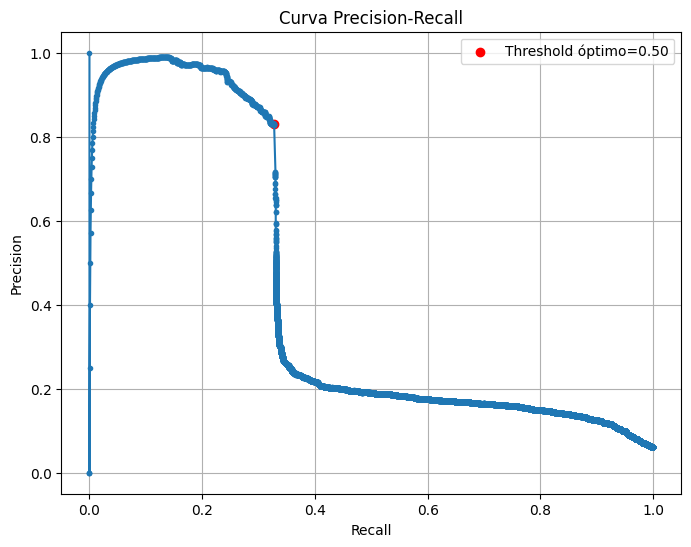

In [79]:
threshold_optimo, resultados = find_optimal_thres(y, y_proba, objetivo="f1", plot=True)

In [80]:
y_pred_thresh = (y_proba >= threshold_optimo).astype(int)

Primeramente pintaremos la curva ROC junto con su valor de AUC

In [81]:
from sklearn.metrics import roc_auc_score
from tqdm import tqdm


def compute_individual_auc(df, y, target_col):
    """
    Computes the individual ROC AUC of each feature against the target.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing features and target
    target_col : str
        Name of the target column (binary: 0/1)
    
    Returns
    -------
    auc_df : pd.DataFrame
        DataFrame with feature name and corresponding AUC score
    """

    auc_list = []
    features = [col for col in df.columns if col not in [target_col]]

    for col in tqdm(features, desc="Computing AUCs"):
        if df[col].nunique() > 1:  # avoid constant columns
            auc = roc_auc_score(y, df[col])
            auc_list.append((col, auc))

    auc_df = pd.DataFrame(auc_list, columns=["feature", "auc"]).sort_values("auc", ascending=False).reset_index(drop=True)
    return auc_df

In [82]:
auc_df = compute_individual_auc(X, y, target_col="target")

print(auc_df.head(30))

Computing AUCs: 100%|██████████| 70/70 [00:00<00:00, 155.99it/s]

                                              feature       auc
0                            consumo_zero_anio_actual  0.780383
1                          consumo_zero_anio_anterior  0.761920
2                       consumo_zero_trimestre_actual  0.713074
3                       consumo_zero_trimestre_pasado  0.703118
4                  consumo_zero_trimestre_anio_pasado  0.696510
5                             consumo_zero_mes_actual  0.680857
6                             consumo_zero_mes_pasado  0.675144
7                        consumo_zero_mes_anio_pasado  0.666638
8                          consumo_zero_semana_actual  0.663087
9                          consumo_zero_semana_pasada  0.659768
10                    consumo_zero_semana_anio_pasado  0.648869
11  porcentaje_calidad_datos_trimestre_pasado_corr...  0.627765
12   porcentaje_calidad_datos_semana_pasada_correctos  0.614982
13      porcentaje_calidad_datos_mes_pasado_correctos  0.612326
14   porcentaje_calidad_datos_anio_anter

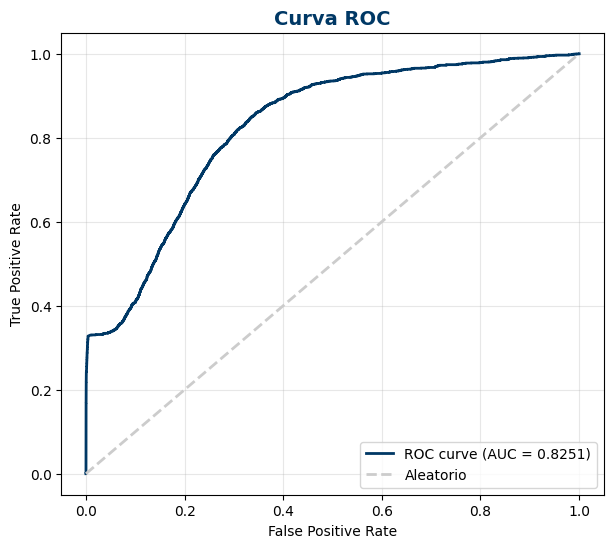

ROC AUC Score: 0.8251


In [83]:
fpr, tpr, thresholds = roc_curve(y, y_proba)
roc_auc = roc_auc_score(y, y_proba)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color=ufd_blue, lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color=ufd_gray, lw=2, linestyle="--", label="Aleatorio")

# Estilo
plt.grid(alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC", fontsize=14, weight="bold", color=ufd_blue)
plt.legend(loc="lower right", fontsize=10)
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")

In [84]:
final_df[top_100_features].corr()

,consumo_zero_anio_actual,consumo_zero_trimestre_actual,consumo_zero_trimestre_pasado,consumo_zero_trimestre_anio_pasado,porcentaje_calidad_datos_mes_actual_correctos,consumo_zero_anio_anterior,consumo_zero_semana_actual,consumo_zero_mes_actual,consumo_zero_mes_anio_pasado,consumo_min_anio_actual,...,consumo_suma_mes_anio_pasado,coef_variacion_trimestre_actual,consumo_stddev_trimestre_pasado,consumo_media_mes_actual,consumo_umbral_mes_pasado,consumo_umbral_semana_anio_pasado,consumo_suma_trimestre_anio_pasado,consumo_min_mes_anio_pasado,consumo_umbral_anio_actual,cnt_eventos_semana_pasada_6_NA
consumo_zero_anio_actual,1.000000,0.955937,0.980400,0.918064,-0.000113,0.886701,0.904166,0.927791,0.923653,-0.020149,...,-0.028400,0.245961,-0.039449,-0.035688,-0.153502,-0.128006,-0.028006,-0.023492,-0.160708,-0.009759
consumo_zero_trimestre_actual,0.955937,1.000000,0.945730,0.837784,0.004415,0.814200,0.959021,0.983130,0.840981,-0.019870,...,-0.027244,0.294670,-0.039087,-0.036733,-0.161346,-0.116360,-0.026859,-0.022618,-0.154098,-0.005234
consumo_zero_trimestre_pasado,0.980400,0.945730,1.000000,0.874528,-0.000012,0.846834,0.884476,0.908082,0.877942,-0.019485,...,-0.027542,0.228786,-0.039588,-0.034763,-0.151067,-0.121417,-0.027248,-0.022492,-0.157253,-0.008939
consumo_zero_trimestre_anio_pasado,0.918064,0.837784,0.874528,1.000000,-0.003917,0.951151,0.793718,0.812660,0.980947,-0.018975,...,-0.028627,0.174970,-0.036116,-0.032831,-0.136446,-0.134473,-0.028544,-0.023590,-0.149573,-0.008825
porcentaje_calidad_datos_mes_actual_correctos,-0.000113,0.004415,-0.000012,-0.003917,1.000000,-0.004584,0.003857,0.005455,-0.002794,0.024920,...,0.079867,-0.020910,0.041106,0.029345,0.560454,0.387234,0.079692,0.019318,0.527497,0.171389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
consumo_umbral_semana_anio_pasado,-0.128006,-0.116360,-0.121417,-0.134473,0.387234,-0.127360,-0.112214,-0.114163,-0.135359,0.122452,...,0.242637,-0.239604,0.175630,0.177795,0.685812,1.000000,0.233608,0.152878,0.803005,0.037399
consumo_suma_trimestre_anio_pasado,-0.028006,-0.026859,-0.027248,-0.028544,0.079692,-0.027686,-0.026027,-0.026421,-0.027903,0.550540,...,0.988593,-0.084521,0.845363,0.923428,0.224269,0.233608,1.000000,0.619057,0.248463,-0.059840
consumo_min_mes_anio_pasado,-0.023492,-0.022618,-0.022492,-0.023590,0.019318,-0.023194,-0.022224,-0.022334,-0.023531,0.880862,...,0.642358,-0.097122,0.369969,0.592500,0.145432,0.152878,0.619057,1.000000,0.169272,-0.050827
consumo_umbral_anio_actual,-0.160708,-0.154098,-0.157253,-0.149573,0.527497,-0.144008,-0.147069,-0.150536,-0.148984,0.145435,...,0.250827,-0.307482,0.228973,0.226121,0.904418,0.803005,0.248463,0.169272,1.000000,0.082063


Mostramos también las curvas de ganancia y lift a continuación

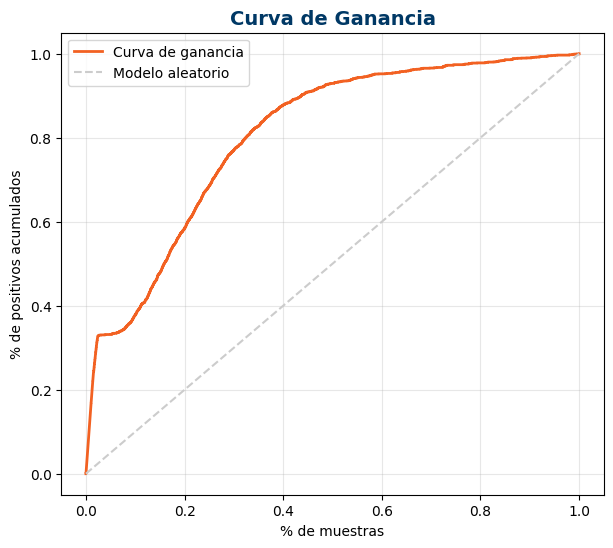

In [85]:
plot_gain(y, y_proba)

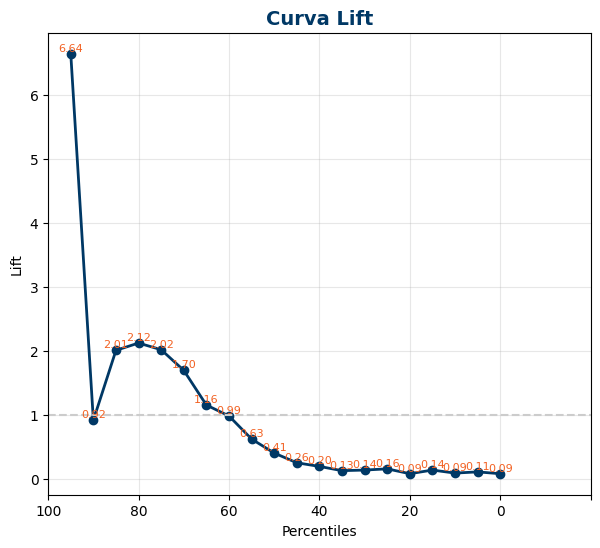

In [86]:
plot_lift(y, y_proba, bins=20)

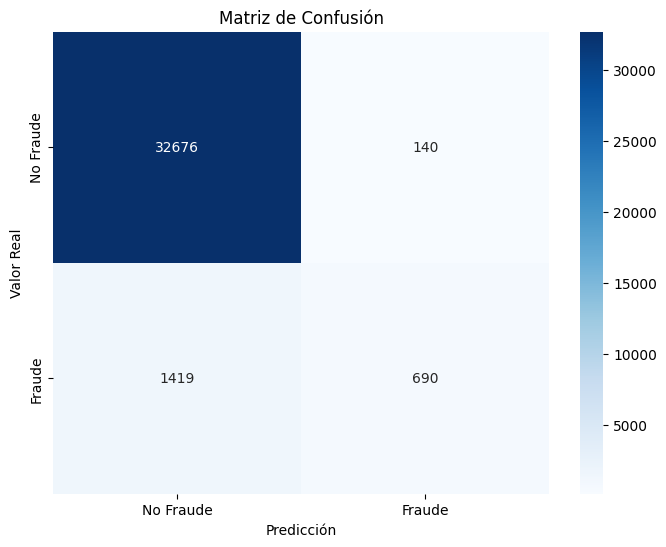


Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.96      1.00      0.98     32816
         1.0       0.83      0.33      0.47      2109

    accuracy                           0.96     34925
   macro avg       0.89      0.66      0.72     34925
weighted avg       0.95      0.96      0.95     34925



In [87]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
cm = confusion_matrix(y, y_pred_thresh)

# Crear una visualización más clara
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Fraude', 'Fraude'], 
            yticklabels=['No Fraude', 'Fraude'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

# También puedes mostrar el reporte de clasificación completo
print("\nReporte de Clasificación:")
print(classification_report(y, y_pred_thresh))

In [88]:
final_df["target"].value_counts()

target
0.0    32816
1.0     2109
Name: count, dtype: int64

In [89]:
# # First, get the indices of the test set in final_df
# test_indices = X_test.index
# train_indices = X_train.index

# # Assign the predicted probabilities to the correct rows
# final_df.loc[test_indices, "xgb_pred_proba"] = y_proba
# final_df.loc[train_indices, "xgb_pred_proba"] = y_proba_train

# final_df.loc[test_indices, "train"] = 0
# final_df.loc[train_indices, "train"] = 1

In [90]:
# final_df["final_scoring"] = final_df["fraude_score_no_supervisado"]*0.3 + final_df["xgb_pred_proba"]*0.7

We define the cuts attending to the lift chart previously defined:

In [91]:
# cuts = [25, 35]  
# thresholds = get_probability_thresholds(y_test, y_proba, cuts)

# print("Thresholds:", thresholds)

We create the new cateogria_fraude column used to order the probabilistic results of the fraud

In [92]:
# conditions = [
#     final_df["final_scoring"] < thresholds[0],                             
#     (final_df["final_scoring"] >= thresholds[0]) & (final_df["final_scoring"] < thresholds[1]),  
#     final_df["final_scoring"] >= thresholds[1]                             
# ]

# choices = ["Bajo", "Medio", "Alto"]

# final_df["categoria_fraude"] = np.select(conditions, choices, default="Bajo")

### 5.4.3. Feature importance

In [93]:
# importance_dict = model.get_booster().get_score(importance_type='gain')

# importance_df = pd.DataFrame({
#     'feature': list(importance_dict.keys()),
#     'importance': [round(value, 3) for value in importance_dict.values()]
# }).sort_values(by='importance', ascending=False)

We make a fast plot in order to visualize the importance

In [94]:
# plt.figure(figsize=(10, 8))
# plot_importance(model, importance_type='gain', max_num_features=20, height=0.5, grid=True)
# plt.title("XGBoost Feature Importance (gain)")
# plt.show()

In [95]:
final_df["target"] = final_df["target"].astype(int)
final_df.head(10)

,cups_sgc,cnt_id,cnt_inspecciones_semana_actual,cnt_inspecciones_semana_pasada,cnt_inspecciones_misma_semana_anio_pasado,cnt_inspecciones_mes_actual,cnt_inspecciones_mes_pasado,cnt_inspecciones_mismo_mes_anio_pasado,cnt_inspecciones_trimestre_actual,cnt_inspecciones_trimestre_pasado,...,reconstruction_error,reconstruction_error_norm,anomaly_autoencoder,lof_scores,lof_probabilities,svm_scores,svm_probabilities,elliptic_scores,elliptic_probabilities,fraude_score_no_supervisado_norm
0,ES0022000001000008QR1P,SAG0185769835,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.167027,0.004861,True,1.042480,1.363593e-10,-21.498105,4.607780e-10,-1.933634e+07,0.996492,-3.222727e+06
1,ES0022000001001149LS1P,SAG0185746454,0.0,0.0,0.0,0.0,28.0,0.0,28.0,0.0,...,0.009115,0.000217,False,1.259406,4.200793e-10,35.403555,1.000000e+00,6.628887e+05,1.000000,1.104877e+05
2,ES0022000001001381YV1P,SAG0186400186,0.0,0.0,0.0,0.0,0.0,27.0,0.0,0.0,...,0.038764,0.001089,False,1.028915,1.186180e-10,33.892575,1.000000e+00,6.045678e+05,0.999990,1.007672e+05
3,ES0022000001001663LT1P,ZIV0036507981,0.0,0.0,0.0,0.0,0.0,31.0,0.0,54.0,...,0.130214,0.003779,True,1.287792,4.572053e-10,10.678191,9.999770e-01,6.595928e+05,0.999999,1.099342e+05
4,ES0022000001002279EH1P,ZIV0047987967,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.160167,0.034073,True,1.754237,1.067271e-09,-77.457090,2.295160e-34,6.111373e+05,0.999991,1.018437e+05
5,ES0022000001002372AL1P,SAG0185734056,0.0,0.0,0.0,0.0,29.0,0.0,29.0,0.0,...,0.040666,0.001145,False,1.499100,7.335755e-10,42.936678,1.000000e+00,6.629192e+05,1.000000,1.104941e+05
6,ES0022000001005251ZT1P,SAG0185729235,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26.0,...,0.009740,0.000235,False,0.998787,7.921363e-11,46.645086,1.000000e+00,6.628720e+05,1.000000,1.104867e+05
7,ES0022000001005425KJ1P,SAG0185748781,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28.0,...,0.005579,0.000113,False,0.989363,6.688759e-11,44.467345,1.000000e+00,6.629774e+05,1.000000,1.105039e+05
8,ES0022000001006539RT1P,ZIV0050276191,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.208056,0.006068,True,1.762653,1.078279e-09,-4.170983,1.520240e-02,6.216100e+05,0.999993,1.036014e+05
9,ES0022000001007458VE1P,SAG0185748789,0.0,0.0,0.0,0.0,0.0,0.0,29.0,26.0,...,0.046955,0.001330,False,1.425471,6.372764e-10,45.393783,1.000000e+00,6.627809e+05,1.000000,1.104714e+05


In [96]:
# First, get the indices of the test set in final_df
indices = X.index

# Assign the predicted probabilities to the correct rows
final_df.loc[indices, "logreg_prediction"] = y_pred_thresh
final_df.loc[indices, "logreg_pred_proba"] = y_proba

In [97]:
final_df["final_scoring"] = final_df["fraude_score_no_supervisado_norm"]*0.3 + final_df["logreg_pred_proba"]*0.7

## 5.5. Evaluating the model

We are going to use the previously trained model to test it in the april data for example. Thus, let's go for it

In [98]:
for col in X:
    if col not in X_eval:
        X_eval[col] = 0

In [99]:
y_proba_eval = model.predict_proba(X_eval[X.columns])[:, 1] 
# y_pred_eval = model.predict(X_eval[X.columns])

# y_pred_eval_thresh, y_proba_eval_thresh = predict_with_threshold(model, X_eval[X.columns], 0.05)

In [100]:
y_pred_eval_thresh = (y_proba_eval >= threshold_optimo).astype(int)

Primeramente pintaremos la curva ROC junto con su valor de AUC

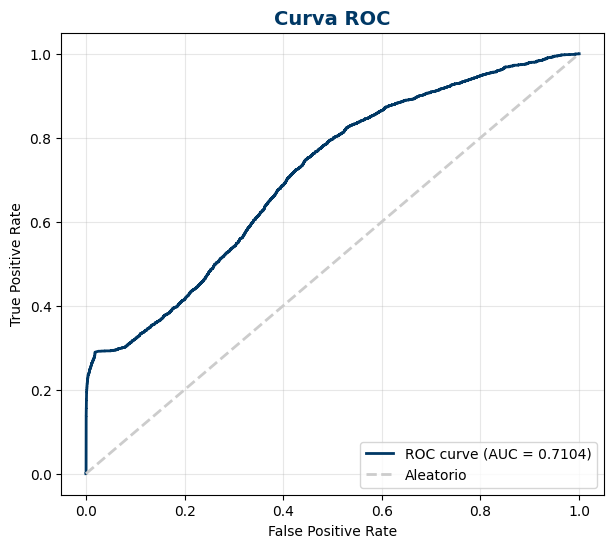

ROC AUC Score: 0.7104


In [101]:
fpr, tpr, thresholds = roc_curve(y_eval, y_proba_eval)
roc_auc_eval = roc_auc_score(y_eval, y_proba_eval)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color=ufd_blue, lw=2, label=f"ROC curve (AUC = {roc_auc_eval:.4f})")
plt.plot([0, 1], [0, 1], color=ufd_gray, lw=2, linestyle="--", label="Aleatorio")

# Estilo
plt.grid(alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC", fontsize=14, weight="bold", color=ufd_blue)
plt.legend(loc="lower right", fontsize=10)
plt.show()

print(f"ROC AUC Score: {roc_auc_eval:.4f}")

Mostramos también las curvas de ganancia y lift a continuación

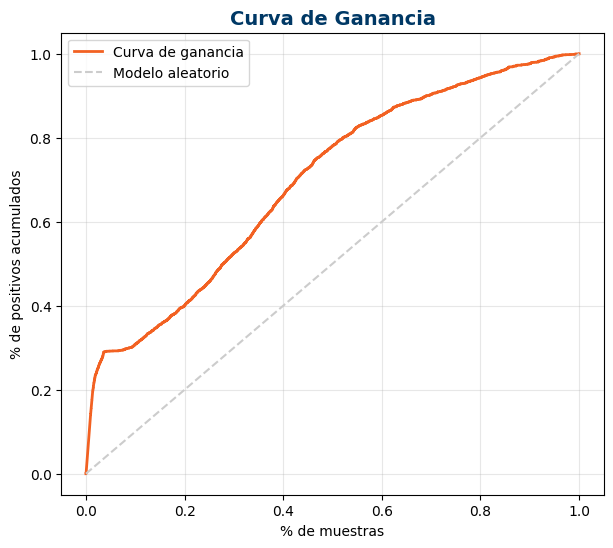

In [102]:
plot_gain(y_eval, y_proba_eval)

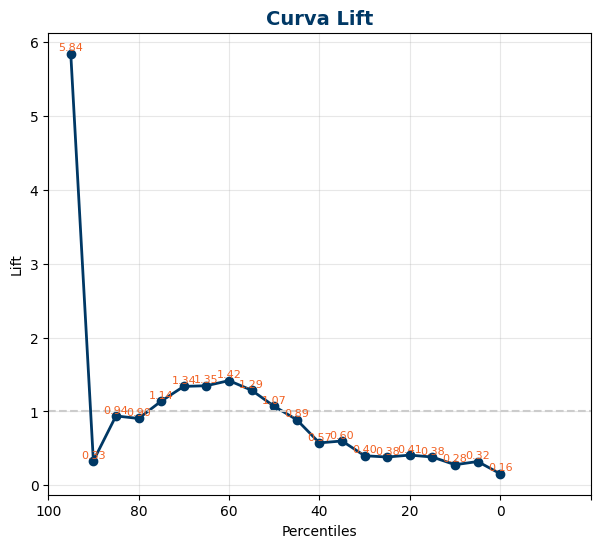

In [103]:
plot_lift(y_eval, y_proba_eval, bins=20)

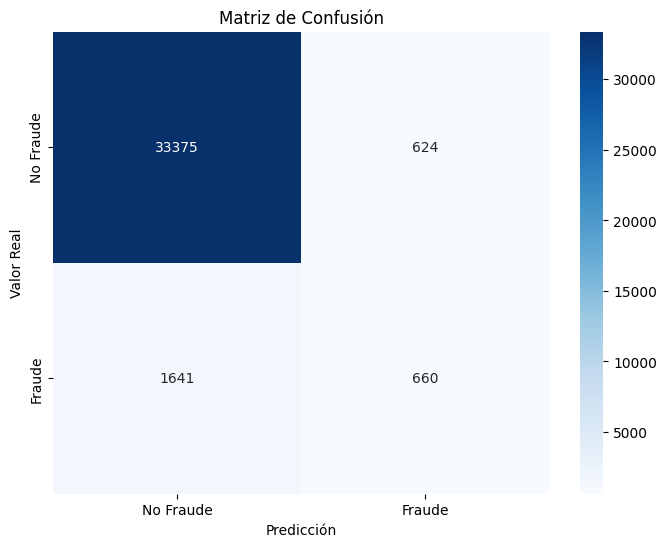


Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.95      0.98      0.97     33999
         1.0       0.51      0.29      0.37      2301

    accuracy                           0.94     36300
   macro avg       0.73      0.63      0.67     36300
weighted avg       0.93      0.94      0.93     36300



In [104]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
cm = confusion_matrix(y_eval, y_pred_eval_thresh)

# Crear una visualización más clara
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Fraude', 'Fraude'], 
            yticklabels=['No Fraude', 'Fraude'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

# También puedes mostrar el reporte de clasificación completo
print("\nReporte de Clasificación:")
print(classification_report(y_eval, y_pred_eval_thresh))

In [105]:
# First, get the indices of the test set in final_df
indices_eval = X_eval.index

# Assign the predicted probabilities to the correct rows
final_df_eval.loc[indices_eval, "logreg_prediction"] = y_pred_eval_thresh
final_df_eval.loc[indices_eval, "logreg_pred_proba"] = y_proba_eval

In [106]:
final_df_eval["final_scoring"] = final_df_eval["fraude_score_no_supervisado_norm"]*0.3 + final_df_eval["logreg_pred_proba"]*0.7

In [107]:
final_df_eval.sort_values("final_scoring", ascending=False)

,cups_sgc,cnt_id,cnt_inspecciones_semana_actual,cnt_inspecciones_semana_pasada,cnt_inspecciones_misma_semana_anio_pasado,cnt_inspecciones_mes_actual,cnt_inspecciones_mes_pasado,cnt_inspecciones_mismo_mes_anio_pasado,cnt_inspecciones_trimestre_actual,cnt_inspecciones_trimestre_pasado,...,lof_scores,lof_probabilities,svm_scores,svm_probabilities,elliptic_scores,elliptic_probabilities,fraude_score_no_supervisado_norm,logreg_prediction,logreg_pred_proba,final_scoring
25635,ES0022000007934261KF1P,CIR0141212615,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.621410,0.091306,22.199257,1.000000,9.826664e+06,1.000000,1.637783e+06,0.0,4.861096e-01,4.913352e+05
6008,ES0022000004752791HN1P,SAG0145201479,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.664271,0.053932,22.200463,1.000000,9.826665e+06,1.000000,1.637782e+06,0.0,4.845015e-01,4.913351e+05
26538,ES0022000008038428LF1P,SAG0125517483,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.279760,0.050300,22.243674,1.000000,9.826664e+06,1.000000,1.637782e+06,0.0,4.305772e-01,4.913350e+05
28207,ES0022000008269606LN1P,SAG0221820268,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.173440,0.020962,22.179900,1.000000,9.826666e+06,1.000000,1.637782e+06,0.0,4.999999e-01,4.913349e+05
7030,ES0022000005016208VX1P,SAG0125704873,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.311235,0.012819,22.125281,1.000000,9.826666e+06,1.000000,1.637782e+06,0.0,4.999999e-01,4.913349e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5175,ES0022000004625530MX1P,SAG0166106531,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.923384,0.009156,-4.873615,0.007588,-2.735677e+10,0.674819,-4.559461e+09,0.0,6.826954e-02,-1.367838e+09
33930,ES0022000008875842LZ1P,ZIV0040116441,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.800995,0.008000,-4.874224,0.007583,-2.772807e+10,0.670407,-4.621345e+09,0.0,4.998704e-01,-1.386403e+09
4187,ES0022000004457848MK1P,ZIV0040111669,0.0,0.0,0.0,0.0,0.0,0.0,0.0,27.0,...,2.137875,0.011181,-4.875210,0.007576,-3.251052e+10,0.613580,-5.418419e+09,0.0,7.605466e-03,-1.625526e+09
25064,ES0022000007855816ZS1P,ZIV0042313874,0.0,0.0,0.0,0.0,28.0,28.0,0.0,28.0,...,3.114504,0.020405,-4.891805,0.007452,-5.751994e+10,0.316408,-9.586657e+09,0.0,2.395643e-12,-2.875997e+09


## 5.6. Dashboard data extraction

Necesitamos extraer ciertos ficheros para la construcción del dashboard en powerbi

In [ ]:
columnas_considerar_preds = ["cups_sgc", "cnt_id", "fraude_score_no_supervisado", 
                             "xgb_pred_proba", "final_scoring", "categoria_fraude", "target", "train"]

In [ ]:
# final_df[columnas_considerar_preds].to_csv("powerbi/predicciones_cups.csv", index=False, sep=";", decimal=",")

In [ ]:
# def lift_at_percentile(y_true, y_proba, percentile=0.1):
#     """
#     Calcula el Lift en el top X% (percentile en [0,1]).
#     """
#     n = int(len(y_proba) * percentile)
#     # Ordenar por probabilidad descendente
#     idx = np.argsort(y_proba)[::-1]
#     y_sorted = np.array(y_true)[idx]
    
#     # Positivos en el top %
#     top_positives = y_sorted[:n].sum()
#     total_positives = y_sorted.sum()
    
#     perc_total = top_positives / total_positives
#     perc_samples = n / len(y_true)
    
#     lift = perc_total / perc_samples
#     return lift, perc_total

# def compute_metrics(y_true, y_proba, dataset_name="test"):
#     auc = roc_auc_score(y_true, y_proba)
#     gini = 2 * auc - 1
#     ks = ks_stat(y_true, y_proba)
#     lift10, capture10 = lift_at_percentile(y_true, y_proba, 0.1)
#     lift20, capture20 = lift_at_percentile(y_true, y_proba, 0.2)

#     return {
#         "dataset": dataset_name,
#         "auc": round(auc, 3),
#         "gini": round(gini, 3),
#         "ks": round(ks, 3),
#         "lift_at_10": lift10,
#         "capture_rate_10": capture10,
#         "lift_at_20": lift20,
#         "capture_rate_20": capture20
#     }

# # =====================
# # Calcular métricas train y test
# # =====================
# metrics_train = compute_metrics(y_train, y_proba_train, dataset_name="train")
# metrics_test = compute_metrics(y_test, y_proba, dataset_name="test")

# model_metrics = pd.DataFrame([metrics_train, metrics_test])
# model_metrics.to_csv("powerbi/model_metrics.csv", index=False, sep=";", decimal=",")

In [ ]:
# fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# roc_data = pd.DataFrame({
#     "fpr": fpr,
#     "tpr": tpr,
#     "threshold": thresholds
# })
# roc_data.to_csv("powerbi/roc_curve.csv", index=False, sep=";", decimal=",")

In [ ]:
# data = list(zip(y_test, y_proba))
# data = sorted(data, key=lambda x: x[1], reverse=True)
# y_sorted = np.array([d[0] for d in data])

# cum_gains = np.cumsum(y_sorted) / sum(y_sorted)
# perc_samples = np.arange(1, len(y_sorted)+1) / len(y_sorted)

# gain_data = pd.DataFrame({
#     "perc_samples": perc_samples,
#     "cum_gains": cum_gains
# })
# gain_data.to_csv("powerbi/gain_curve.csv", index=False, sep=";", decimal=",")

In [ ]:
# def compute_lift(y_true, y_proba, bins=20):
#     data = list(zip(y_true, y_proba))
#     data = sorted(data, key=lambda x: x[1], reverse=True)
#     y_sorted = np.array([d[0] for d in data])

#     total_rate = sum(y_sorted) / len(y_sorted)
#     group_size = len(y_sorted) // bins
#     lift_values, percentiles = [], []

#     for i in range(bins):
#         start = i * group_size
#         end = (i+1) * group_size if i < bins-1 else len(y_sorted)
#         group = y_sorted[start:end]
#         group_rate = sum(group) / len(group)
#         lift = group_rate / total_rate
#         lift_values.append(lift)
#         percentiles.append(100 - (i+1)*(100//bins))  # de 100 a 0

#     return pd.DataFrame({
#         "percentil": percentiles,
#         "lift": lift_values
#     })

# lift_data = compute_lift(y_test, y_proba, bins=20)
# lift_data.to_csv("powerbi/lift_curve.csv", index=False, sep=";", decimal=",")

In [ ]:
# 'dataset' contiene los datos de entrada para este script
# import pandas as pd
# from pyproj import Transformer

# # dataset = tabla que llega desde Power BI
# df = pd.read_csv("coordenadas_contadores.csv")

# # Convertir a numérico (si hay valores raros, los pone como NaN)
# df["coord_utm_x_bdi"] = pd.to_numeric(df["coord_utm_x_bdi"], errors="coerce")
# df["coord_utm_y_bdi"] = pd.to_numeric(df["coord_utm_y_bdi"], errors="coerce")

# # Crear transformador (UTM zona 30N -> WGS84)
# transformer = Transformer.from_crs("EPSG:25830", "EPSG:4326", always_xy=True)

# # Transformar coordenadas (saltará NaN si alguna fila no tenía valores válidos)
# df["longitud"], df["latitud"] = transformer.transform(
#     df["coord_utm_x_bdi"].values,
#     df["coord_utm_y_bdi"].values
# )

# df.to_csv("coordenadas_contadores_lat_long.csv", index=False, decimal=",", sep=";")


In [ ]:
# df.head(10)

In [ ]:
# color1 = "#cccccc"
# color2 = "#003865"

In [ ]:
# def lift_chart_plot(y_test, predict_proba_test, num_chunks = None, cuts = None, color1 = color1, color2 = color2):
#     """
#     Generates the lift chart with the standard visualization.
    
#     Parameters:
#         - y_test: `DataFrame`. Object with data regarding the target variable. It corresponds to the dataset left aside for the testing phase.
#         - predict_proba_test: `list` of `float`. Object with the predicted probabilites for the given model to study.
#         - num_chunks: `int`. Number of equivalent groups into which the gain porportion will be studies (2: for 50% and 100%)
#         - cuts: `list` of `float`. Specific decimal amount of register for which to calculate gain proportion (values from 0 to 1)
#         - color1: `str`. Color code for plot representation.
#         - color2: `str`. Color code for plot representation.

#     Returns: 
#         Plot of lift chart.
#     """    
#     values = sorted([(true, proba) for true, proba in zip(y_test, predict_proba_test)], key=lambda x: -x[1])
#     sorted_labels = [x[0] for x in values]
    
#     num_points = len(sorted_labels)
#     percent_1s = sum(sorted_labels)/num_points
    
#     if num_chunks is not None:
#         percent_chunks = [ i/num_chunks for i in range(1, num_chunks+1)]
        
#     if cuts is not None:
#         percent_chunks = cuts
    
#     index_chunks = [0]+[round(num_points*perc) for perc in percent_chunks]
    
#     y_values = [round((sum(sorted_labels[index_chunks[index]:index_chunks[index+1]])/
#                        len(sorted_labels[index_chunks[index]:index_chunks[index+1]]))/percent_1s, 2)
#                 for index in range(len(index_chunks)-1)]
#     x_values = [round(percent*100,2) for percent in percent_chunks]
    
#     plt.plot(x_values, y_values, marker='o', color = color2)
#     plt.plot([0,100], [1,1], color=color1)
#     plt.xlabel('Porcentaje de contadores', fontsize=14, weight='bold')
#     plt.xticks(x_values)
#     plt.xlim([x_values[0], x_values[-1]])
#     plt.ylabel('Valor LIFT', fontsize=14, weight='bold')
#     plt.title('Curva LIFT', fontsize=18, weight='bold')
#     for x, y in zip(x_values, y_values):
#         plt.annotate(f'{y}', (x,y), (x, y+0.07))
#     plt.show()

In [ ]:
# lift_chart_plot(y_test, y_proba, num_chunks=10, color1=color1, color2=color2)